# Laboratorio 2 - Deep Learning
## Modelos LSTM para series de tiempo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Ejercicio 1

## 1.1
### Carga de las series a analizar

Se utilizarán dos series únicamente: la serie del total de visitantes y de entrada vía marítima.

In [3]:
# Dataset de total
train = pd.read_csv(
    "total_train.csv",
    index_col=0,
    parse_dates=True
)

test = pd.read_csv(
    "total_test.csv",
    index_col=0,
    parse_dates=True
)

train = train["viajeros"]
test = test["viajeros"]


# Dataset de aérea
train2 = pd.read_csv(
    "aerea_train.csv",
    index_col=0,
    parse_dates=True
)

test2 = pd.read_csv(
    "aerea_test.csv",
    index_col=0,
    parse_dates=True
)

train2 = train2["viajeros"]
test2 = test2["viajeros"]

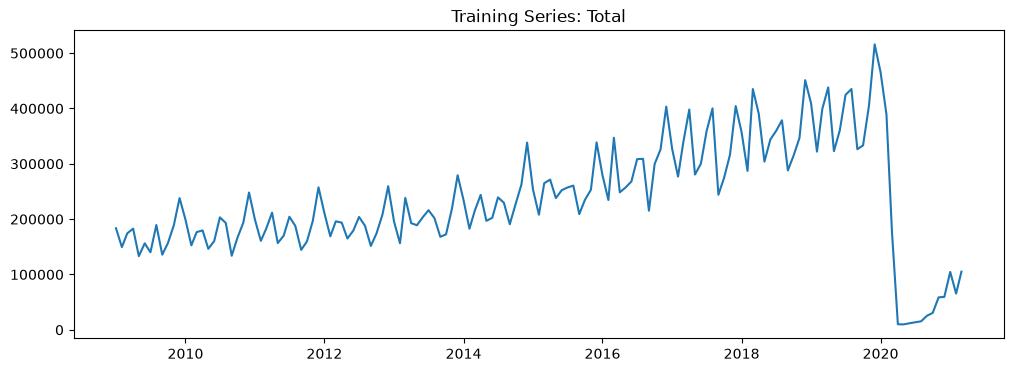

In [4]:
plt.figure(figsize=(12,4))
plt.plot(train)
plt.title("Training Series: Total")
plt.show()

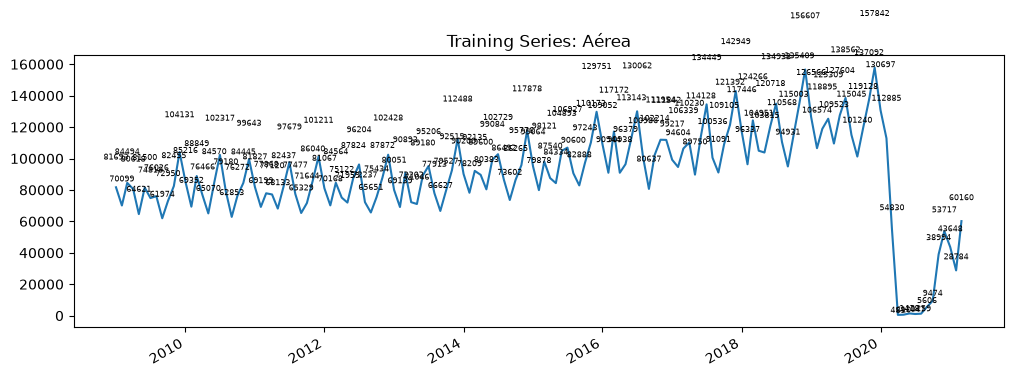

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(train2)

# ---- NEW CODE TO ADD NUMBERS ----
# Loop through the index (dates) and values of your series
for date, value in train2.items():
    # Adjust the positioning (value + offset) so text doesn't sit on the line
    # For integers, convert to string. For decimals, use f"{value:.1f}" to round.
    plt.text(date, value + (value * 0.2), str(int(value)), 
             ha='center', va='bottom', fontsize=6, color='black')
# ---------------------------------

plt.title("Training Series: Aérea")
plt.gcf().autofmt_xdate() # Rotates the dates so they don't overlap
plt.show()

### Normalización

Reducir la escala de los datos para facilitar el aprendizaje de la red neuronal

In [6]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
test_scaled = scaler.transform(test.values.reshape(-1,1))

scaler_aerea = MinMaxScaler()
train2_scaled = scaler_aerea.fit_transform(train2.values.reshape(-1,1))
test2_scaled = scaler_aerea.transform(test2.values.reshape(-1,1))

### Ventanas de tiempo
Se utilizarán los últimos 12 meses para predecir el siguiente mes

In [7]:
LOOK_BACK = 12

def create_dataset(data, look_back):

    X = []
    y = []

    for i in range(len(data)-look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])

    return np.array(X), np.array(y)

In [8]:
X_train, y_train = create_dataset(train_scaled, LOOK_BACK)
X_test, y_test = create_dataset(test_scaled, LOOK_BACK)

X_train2, y_train2 = create_dataset(train2_scaled, LOOK_BACK)
X_test2, y_test2 = create_dataset(test2_scaled, LOOK_BACK)

In [9]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Aérea
X_train2 = torch.tensor(X_train2, dtype=torch.float32)
y_train2 = torch.tensor(y_train2, dtype=torch.float32)
X_test2 = torch.tensor(X_test2, dtype=torch.float32)
y_test2 = torch.tensor(y_test2, dtype=torch.float32)    

### Carga de datos

In [10]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=8,
    shuffle=False
)

train_loader2 = DataLoader(
    TensorDataset(X_train2, y_train2),
    batch_size=8,
    shuffle=False
)

### Clase de LSTM para los 2 modelos

In [11]:
class LSTMModel(nn.Module):

    def __init__(self, hidden):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden,
            batch_first=True
        )

        self.fc = nn.Linear(hidden,1)

    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out)

### Función de entrenamiento

In [12]:
def train_model(model, train_loader, epochs):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(epochs):

        model.train()
        epoch_loss = 0

        for X, y in train_loader:

            optimizer.zero_grad()

            pred = model(X)

            loss = criterion(pred, y)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss)

    return losses

## 1.2 Modelos LSTM

#### Modelo 1

In [13]:
model1 = LSTMModel(hidden=32)

loss1 = train_model(
    model1,
    train_loader,
    epochs=50
)

# SERIE AÉREA
model1_air = LSTMModel(hidden=32)

loss1_air = train_model(
    model1_air,
    train_loader2,
    epochs=50
)      

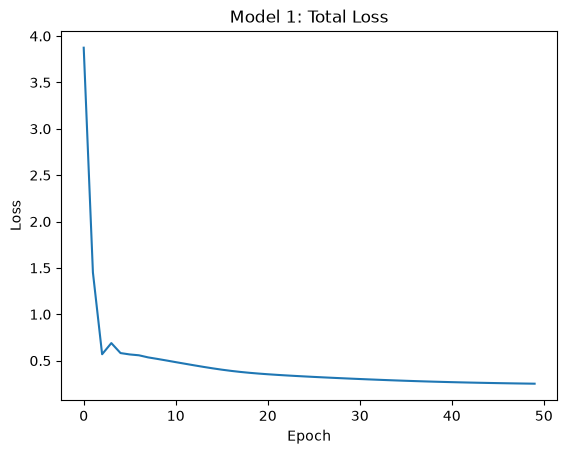

In [14]:
plt.plot(loss1)
plt.title("Model 1: Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

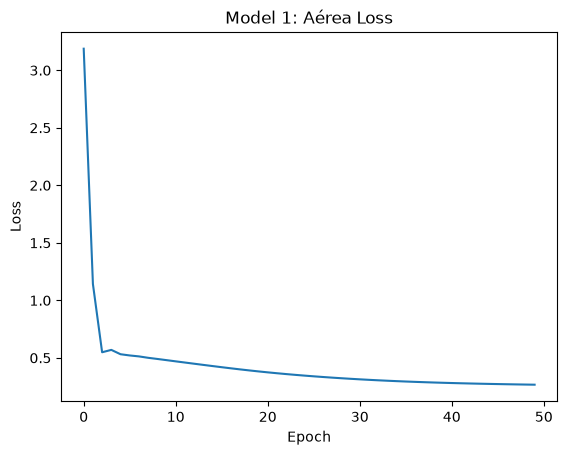

In [15]:
plt.plot(loss1_air)
plt.title("Model 1: Aérea Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Ambos modelos parecen reducir su error de predicción considerablemente conforme la cantidad de veces que han revisado el dataset de training ha aumentado.

#### Modelo 2

Incluye cambio de parámetros en hidden units y epochs.

In [16]:
model2 = LSTMModel(hidden=64)

loss2 = train_model(
    model2,
    train_loader,
    epochs=100
)

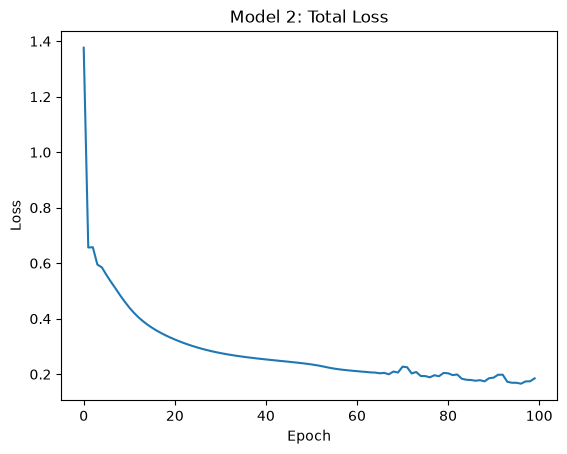

In [17]:
plt.plot(loss2)
plt.title("Model 2: Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [18]:
model2_air = LSTMModel(hidden=64)

loss2_air = train_model(
    model2_air, 
    train_loader2,
    epochs=100
)

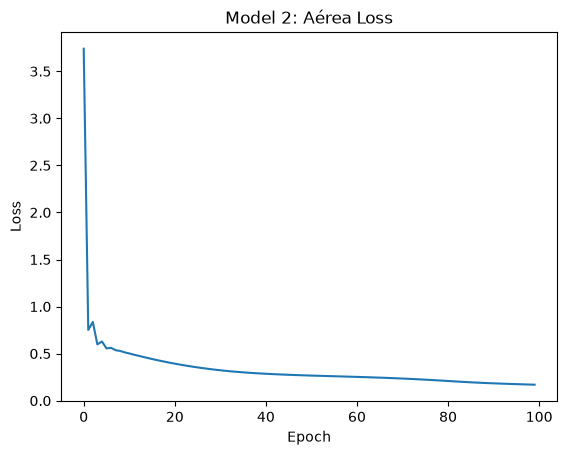

In [19]:
plt.plot(loss2_air)
plt.title("Model 2: Aérea Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 1.3 Predicciones
### Función de predicción

In [20]:
def predict(model,X, scaler):

    model.eval()

    with torch.no_grad():

        pred = model(X).numpy()

    return scaler.inverse_transform(pred)

pred1 = predict(model1, X_test, scaler)
pred2 = predict(model2, X_test, scaler)

real = scaler.inverse_transform(y_test.numpy())

# Segunda serie: Aérea

pred1_air = predict(model1_air, X_test2, scaler_aerea)
pred2_air = predict(model2_air, X_test2, scaler_aerea)

#regresar a la escala original
real_air = scaler_aerea.inverse_transform(y_test2.numpy())

In [21]:
## METRICAS
def evaluate(real,pred):

    rmse = np.sqrt(mean_squared_error(real,pred))
    mae = mean_absolute_error(real,pred)

    mape = np.mean(
        np.abs((real-pred)/real)
    )*100

    return rmse,mae,mape

rmse1,mae1,mape1 = evaluate(real,pred1)
rmse2,mae2,mape2 = evaluate(real,pred2)

# Métricas Aérea

rmse1_air,mae1_air,mape1_air = evaluate(real_air,pred1_air)
rmse2_air,mae2_air,mape2_air = evaluate(real_air,pred2_air)

results = pd.DataFrame({

    "Model":[
        "LSTM 1",
        "LSTM 2",
        "LSTM 1",
        "LSTM 2"
    ],

    "Series":[
        "Total",
        "Total",
        "Aérea",
        "Aérea"
    ],

    "RMSE":[
        rmse1,
        rmse2,
        rmse1_air,
        rmse2_air
    ],

    "MAE":[
        mae1,
        mae2,
        mae1_air,
        mae2_air
    ],

    "MAPE":[
        mape1,
        mape2,
        mape1_air,
        mape2_air
    ]
})

results

,Model,Series,RMSE,MAE,MAPE
0,LSTM 1,Total,60122.948165,46381.347656,15.295222
1,LSTM 2,Total,56915.207107,44240.406250,14.822017
2,LSTM 1,Aérea,18342.382833,15077.523438,15.991752
3,LSTM 2,Aérea,17302.336490,13291.737305,14.022600


### Predicciones: visualización

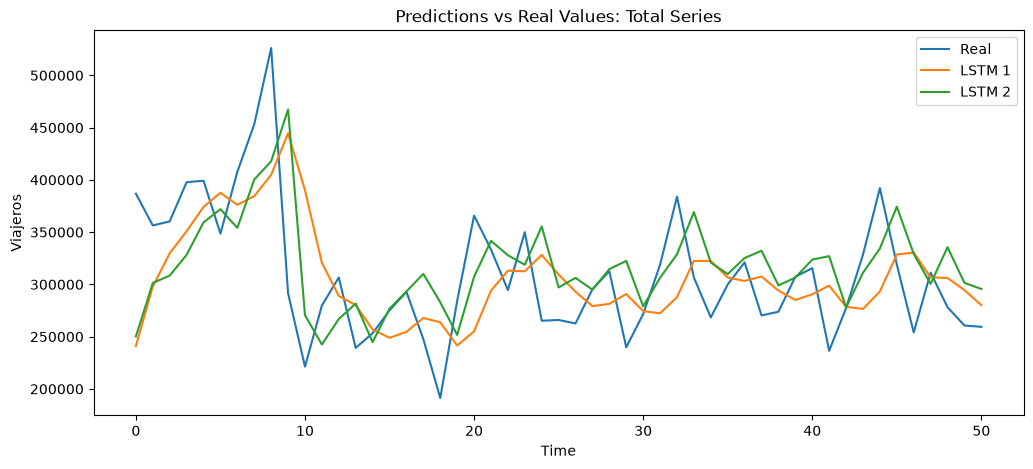

In [22]:
plt.figure(figsize=(12,5))

plt.title("Predictions vs Real Values: Total Series")

plt.xlabel("Time")
plt.ylabel("Viajeros")


plt.plot(real,label="Real")

plt.plot(pred1,label="LSTM 1")

plt.plot(pred2,label="LSTM 2")

plt.legend()

plt.show()

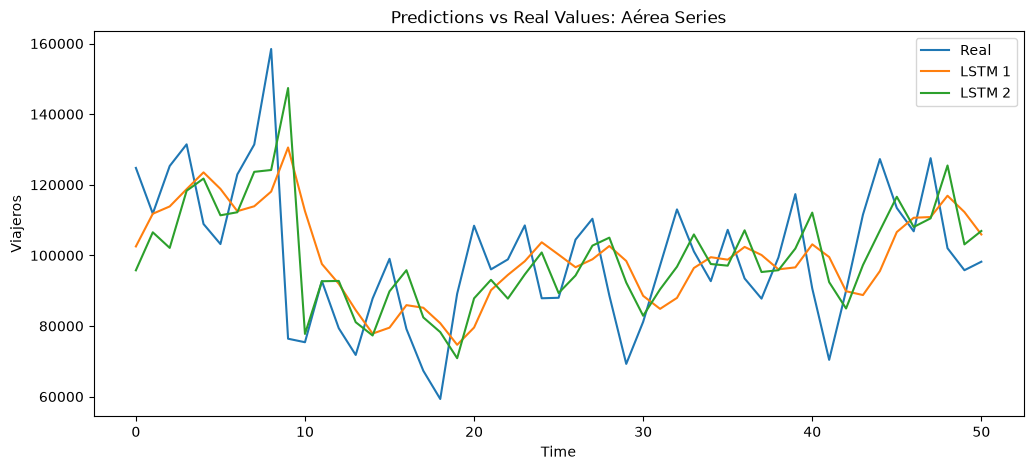

In [23]:
plt.figure(figsize=(12,5))

plt.title("Predictions vs Real Values: Aérea Series")

plt.xlabel("Time")
plt.ylabel("Viajeros")


plt.plot(real_air,label="Real")

plt.plot(pred1_air,label="LSTM 1")

plt.plot(pred2_air,label="LSTM 2")

plt.legend()

plt.show()

In [24]:
best = results.loc[results.groupby("Series")["RMSE"].idxmin()]

print(best)

    Model Series          RMSE           MAE       MAPE
3  LSTM 2  Aérea  17302.336490  13291.737305  14.022600
1  LSTM 2  Total  56915.207107  44240.406250  14.822017


Es evidente que el modelo 2 presentó mayor precisión por la escala de su error medio.

In [25]:
comparison = pd.DataFrame({

    "Model":[
        "Holt-Winters",
        "LSTM 1",
        "LSTM 2",
        "Holt-Winters",
        "LSTM 1",
        "LSTM 2"
    ],

    "Series":[
        "Total",
        "Total",
        "Total",
        "Aérea",
        "Aérea",
        "Aérea"
    ],

    "RMSE":[
        168288.8,     
        rmse1,
        rmse2,
        29846.3,
        rmse1_air,  
        rmse2_air
    ],

    "MAE":[
        148782.5,     
        mae1,
        mae2,
        24619.3,
        mae1_air,
        mae2_air
    ],

    "MAPE":[
        48.8,     
        mape1,
        mape2,
        24.3,
        mape1_air,
        mape2_air
    ]



})

comparison

,Model,Series,RMSE,MAE,MAPE
0,Holt-Winters,Total,168288.800000,148782.500000,48.800000
1,LSTM 1,Total,60122.948165,46381.347656,15.295222
2,LSTM 2,Total,56915.207107,44240.406250,14.822017
3,Holt-Winters,Aérea,29846.300000,24619.300000,24.300000
4,LSTM 1,Aérea,18342.382833,15077.523438,15.991752
5,LSTM 2,Aérea,17302.336490,13291.737305,14.022600


A comparación del modelo de Holt-Winters, ambos modelos de Deep Learning evidencian un mayor rendimiento para hacer predicciones. Ahora, entre dichos modelos, el segundo resultó ser el mejor candidato porque cuenta con un mayor número de neuronas y más épocas de entrenamiento, lo que le permite aprender patrones temporales más complejos, como la tendencia y la estacionalidad presentes en la serie de viajeros. 

En este caso el Modelo 2, que tiene arquitectura de mayor complejidad fue necesaria para generalizar la predicción.